<a href="https://colab.research.google.com/github/AnnisaFarikha/Kecerdasan-Buatan/blob/main/Jobsheet_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Library dan Load Data

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset dari URL Microsoft yang dijamin aktif
url = 'https://raw.githubusercontent.com/MicrosoftDocs/mslearn-aml-labs/master/data/daily-bike-share.csv'
df = pd.read_csv(url)

# Menyesuaikan nama kolom agar cocok dengan script kita
df.rename(columns={'dteday': 'dteday', 'weathersit': 'weathersit'}, inplace=True)

# Mapping angka kategori menjadi teks agar mudah dibaca
season_labels = {1: 'Musim Semi', 2: 'Musim Panas', 3: 'Musim Gugur', 4: 'Musim Dingin'}
weather_labels = {1: 'Cerah', 2: 'Mendung', 3: 'Hujan Ringan/Salju', 4: 'Cuaca Ekstrem'}

df['season_name'] = df['season'].map(season_labels)
df['weather_name'] = df['weathersit'].map(weather_labels)

# Menampilkan 5 baris pertama data
df.head()

,day,mnth,year,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,season_name,weather_name
0,1,1,2011,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,Musim Semi,Mendung
1,2,1,2011,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,Musim Semi,Mendung
2,3,1,2011,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,Musim Semi,Cerah
3,4,1,2011,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,Musim Semi,Cerah
4,5,1,2011,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,Musim Semi,Cerah


##Pertanyaan Bisnis:
###1. Bagaimana pengaruh kondisi cuaca (weather) terhadap rata-rata jumlah penyewaan sepeda harian?
###2. Bagaimana tingkat penyewaan sepeda pada setiap musim (season)?

##Eksplorasi Data (EDA) dengan Statistik Deskriptif

In [10]:
print("=== 1. EDA Pertanyaan 1: Rata-rata Penyewaan berdasarkan Cuaca ===")
eda_cuaca = df.groupby('weather_name')['rentals'].agg(['mean', 'median', 'min', 'max', 'count']).reset_index()
display(eda_cuaca)

print("\n=== 2. EDA Pertanyaan 2: Rata-rata Penyewaan berdasarkan Musim ===")
eda_musim = df.groupby('season_name')['rentals'].agg(['mean', 'median', 'min', 'max', 'count']).reset_index()
display(eda_musim)

=== 1. EDA Pertanyaan 1: Rata-rata Penyewaan berdasarkan Cuaca ===


,weather_name,mean,median,min,max,count
0,Cerah,964.030238,829.0,15,3410,463
1,Hujan Ringan/Salju,185.476190,126.0,2,1264,21
2,Mendung,687.352227,534.0,9,3155,247



=== 2. EDA Pertanyaan 2: Rata-rata Penyewaan berdasarkan Musim ===


,season_name,mean,median,min,max,count
0,Musim Dingin,729.112360,544.5,2,3031,178
1,Musim Gugur,1202.611702,1050.5,118,3160,188
2,Musim Panas,1106.097826,867.0,120,3410,184
3,Musim Semi,334.928177,218.0,9,3155,181


##Visualisasi Data

/tmp/ipykernel_5972/2395877336.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_name', y='rentals', data=df, estimator=np.mean, errorbar=None, palette='Blues_d')
/tmp/ipykernel_5972/2395877336.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season_name', y='rentals', data=df, estimator=np.mean, errorbar=None, palette='Set2')


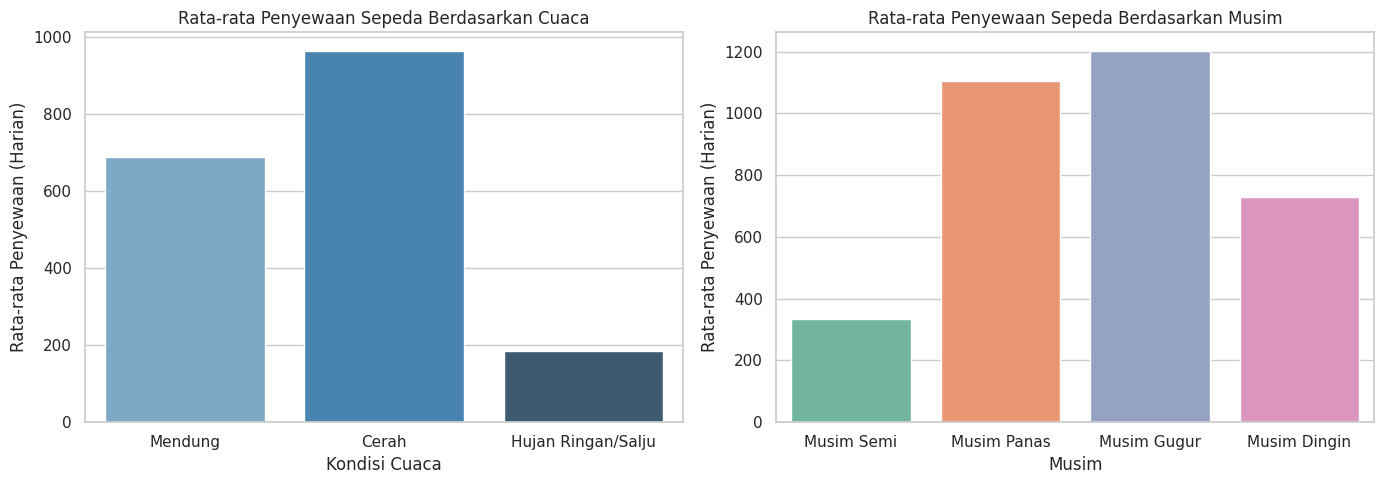

In [11]:
# Set style grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Visualisasi 1: Pengaruh Cuaca terhadap Jumlah Penyewaan
plt.subplot(1, 2, 1)
sns.barplot(x='weather_name', y='rentals', data=df, estimator=np.mean, errorbar=None, palette='Blues_d')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Cuaca', fontsize=12)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan (Harian)')

# Visualisasi 2: Jumlah Penyewaan Berdasarkan Musim
plt.subplot(1, 2, 2)
sns.barplot(x='season_name', y='rentals', data=df, estimator=np.mean, errorbar=None, palette='Set2')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim', fontsize=12)
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan (Harian)')

plt.tight_layout()
plt.show()